### Notes

In [1]:

import os
import sys
sys.path.append('/home/hengjie/DL_projects/brainmets/1210_wip/0107')
from myRTDoseReader import myRTDoseReader

dir_base = "/database/brainmets/dicom/SBRT_research_mim_export_20251209_organized"


# # 0944.1998.11 (fail)
path_dict = {
    "MR":     "SRS0944/1998-11__Studies/SRS0944_SRS0944_MR_1998-11-12_000000_._axial_n45__00000",
    "RTDOSE": "SRS0944/1998-11__Studies/SRS0944_SRS0944_RTDOSE_1998-11-12_000000_._._n1__00000",
}

# 3126.2021.01 (success)
# path_dict = {
#     "MR":     "SRS3126/2011-01__Studies/SRS3126_SRS3126_MR_2011-01-07_083714_MR.STEREO.BRAIN_AX.T1.PG_n51__00000",
#     "RTDOSE": "SRS3126/2011-01__Studies/SRS3126_SRS3126_RTDOSE_2011-01-07_083714_MR.STEREO.BRAIN_._n1__00000",
# }


# 1669.2002.03 (fail)
# path_dict = {
#     "MR":     "SRS1669/2002-03__Studies/SRS1669_SRS1669_MR_2002-03-12_000000_._axial1_n22__00000",
#     "RTDOSE": "SRS1669/2002-03__Studies/SRS1669_SRS1669_RTDOSE_2002-03-12_000000_._._n1__00000",
# }

# 1669.2010.10 (success)
# path_dict = {
#     "MR":     "SRS1669/2010-10__Studies/SRS1669_SRS1669_MR_2010-10-04_091759_MR.STEREO.BRAIN_Ax.T1.PG_n51__00000",
#     "RTDOSE": "SRS1669/2010-10__Studies/SRS1669_SRS1669_RTDOSE_2010-10-04_091759_MR.STEREO.BRAIN_._n1__00000",
# }

folder_mr = os.path.join(dir_base, path_dict["MR"])
folder_rtdose = os.path.join(dir_base, path_dict["RTDOSE"])

In [2]:
import os
import SimpleITK as sitk


def _get_dicom_tag_as_str(path: str, tag: str, load_private: bool = True) -> str | None:
    """Read a single DICOM tag as string via SimpleITK without loading pixels."""
    r = sitk.ImageFileReader()
    r.SetFileName(path)
    if load_private:
        r.LoadPrivateTagsOn()
    try:
        r.ReadImageInformation()
    except Exception:
        return None
    if r.HasMetaDataKey(tag):
        return r.GetMetaData(tag)
    return None


def _parse_dicom_floats(s: str | None) -> tuple[float, ...] | None:
    if not s:
        return None
    parts = s.replace(",", "\\").split("\\")
    try:
        return tuple(float(p) for p in parts if p != "")
    except ValueError:
        return None


def read_dicom_series(
    folder: str,
    series_uid: str | None = None,
    debug: bool = False,
) -> tuple[sitk.Image, list[str], str]:
    """
    Read a DICOM series (3D volume) from a folder.

    If series_uid is None, it picks the series with the most slices.
    Returns (image, file_list, chosen_series_uid).
    """
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Not a folder: {folder}")

    series_ids = sitk.ImageSeriesReader.GetGDCMSeriesIDs(folder)
    if not series_ids:
        raise RuntimeError(f"No DICOM series found in: {folder}")

    if series_uid is None:
        # pick the series with the most files (often the actual volume, but not guaranteed)
        best_id = None
        best_n = -1
        for sid in series_ids:
            files = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(folder, sid)
            if len(files) > best_n:
                best_n = len(files)
                best_id = sid
        series_uid = best_id

    # IMPORTANT: GetGDCMSeriesFileNames returns a geometry-sorted list
    file_list = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(folder, series_uid)
    if not file_list:
        raise RuntimeError(f"Series UID {series_uid} has no files in: {folder}")

    if debug:
        # Use first slice’s IOP to compute a slice normal; then project IPP onto it to verify order.
        iop_str = _get_dicom_tag_as_str(file_list[0], "0020|0037")
        iop = _parse_dicom_floats(iop_str)  # 6 floats: row(3), col(3)
        normal = None
        if iop and len(iop) == 6:
            row = iop[0:3]
            col = iop[3:6]
            # cross product row x col
            normal = (
                row[1] * col[2] - row[2] * col[1],
                row[2] * col[0] - row[0] * col[2],
                row[0] * col[1] - row[1] * col[0],
            )

        print(f"[DEBUG] Chosen SeriesInstanceUID: {series_uid}")
        print(f"[DEBUG] Number of files: {len(file_list)}")
        if iop:
            print(f"[DEBUG] IOP (0020,0037) from first slice: {iop}")
        if normal:
            print(f"[DEBUG] Slice normal (row x col): {normal}")

        print("[DEBUG] Sorted slices (in returned order):")
        for i, fp in enumerate(file_list):
            inst_str = _get_dicom_tag_as_str(fp, "0020|0013")  # InstanceNumber
            ipp_str = _get_dicom_tag_as_str(fp, "0020|0032")   # ImagePositionPatient
            ipp = _parse_dicom_floats(ipp_str)

            s_coord = None
            if normal and ipp and len(ipp) == 3:
                s_coord = ipp[0] * normal[0] + ipp[1] * normal[1] + ipp[2] * normal[2]

            base = os.path.basename(fp)
            if ipp and len(ipp) == 3:
                if s_coord is None:
                    print(f"  {i:04d}  {base}  Instance={inst_str}  IPP={ipp}")
                else:
                    print(f"  {i:04d}  {base}  Instance={inst_str}  IPP={ipp}  s={s_coord:.6f}")
            else:
                print(f"  {i:04d}  {base}  Instance={inst_str}  IPP=<missing/unparseable>")

    # reader = sitk.ImageSeriesReader()
    # reader.SetFileNames(file_list)

    # # optional but often helpful for DICOM:
    # reader.MetaDataDictionaryArrayUpdateOn()
    # reader.LoadPrivateTagsOn()

    # img3d = reader.Execute()

    reader = sitk.ImageSeriesReader()
    reader.SetFileNames(file_list)
    reader.MetaDataDictionaryArrayUpdateOn()
    reader.LoadPrivateTagsOn()
    
    img3d = reader.Execute()

    # CHECK: Did sitk fallback to default (0,0,0) origin?
    # if img3d.GetOrigin() == (0.0, 0.0, 0.0) and len(file_list) > 1:
    if True:
        if debug:
            print("[FIX] SimpleITK triggered default geometry. Manually restoring...")

        # A. Restore Origin
        first_ipp = _parse_dicom_floats(_get_dicom_tag_as_str(file_list[0], "0020|0032"))
        img3d.SetOrigin(first_ipp)

        # B. Restore Direction (Orientation)
        # Get the row and column cosines
        iop = _parse_dicom_floats(_get_dicom_tag_as_str(file_list[0], "0020|0037"))
        if iop and len(iop) == 6:
            r = iop[0:3]
            c = iop[3:6]
            # Cross product for the Z-axis (normal)
            n = (
                r[1] * c[2] - r[2] * c[1],
                r[2] * c[0] - r[0] * c[2],
                r[0] * c[1] - r[1] * c[0]
            )
            # SITK expects a flattened 3x3 matrix: (r_x, r_y, r_z, c_x, c_y, c_z, n_x, n_y, n_z)
            img3d.SetDirection(r + c + n)

        # C. Restore Spacing
        # Pixel Spacing (X, Y)
        px_spacing = _parse_dicom_floats(_get_dicom_tag_as_str(file_list[0], "0028|0030"))
        # Z-Spacing calculated from the distance between first two IPPs
        ipp1 = _parse_dicom_floats(_get_dicom_tag_as_str(file_list[1], "0020|0032"))
        
        # Calculate Euclidean distance between IPP0 and IPP1 for true slice thickness/spacing
        import math
        dz = math.sqrt(sum([(a - b) ** 2 for a, b in zip(first_ipp, ipp1)]))
        
        img3d.SetSpacing((px_spacing[0], px_spacing[1], dz))

    return img3d, file_list, series_uid

    if debug:
        print("[DEBUG] Output SimpleITK image geometry:")
        print("  size     :", img3d.GetSize())
        print("  spacing  :", img3d.GetSpacing())
        print("  origin   :", img3d.GetOrigin())
        print("  direction:", img3d.GetDirection())
        # For most series, origin should match IPP of file_list[0] (up to tiny rounding)
        ipp0 = _parse_dicom_floats(_get_dicom_tag_as_str(file_list[0], "0020|0032"))
        print("  IPP(first slice):", ipp0)

    return img3d, file_list, series_uid



def resample_to_reference(
    moving: sitk.Image,
    reference: sitk.Image,
    *,
    transform: sitk.Transform | None = None,
    interpolator: int | None = None,
    default_value: float = 0.0,
    output_pixel_type: int | None = None,
) -> sitk.Image:
    """
    Resample `moving` onto the grid of `reference`.

    Parameters
    ----------
    moving : sitk.Image
        Image to be resampled (e.g., RTDOSE).
    reference : sitk.Image
        Target grid (e.g., CT/MR DICOM image) providing spacing/origin/direction/size.
    transform : sitk.Transform | None
        Physical transform mapping reference -> moving. For same patient space, use identity.
        If you already registered images, pass that transform here.
    interpolator : int | None
        sitk interpolator. If None, auto-choose:
          - sitkLinear for scalar images (dose, CT, MR)
          - sitkNearestNeighbor for labels (mask)
    default_value : float
        Value for samples outside moving image support (dose outside grid -> 0).
    output_pixel_type : int | None
        Output pixel type. If None, keep moving's pixel type.

    Returns
    -------
    sitk.Image
        moving resampled onto reference grid.
    """
    if transform is None:
        transform = sitk.Transform(3, sitk.sitkIdentity)

    if interpolator is None:
        # Heuristic: use NN for integer-ish label images, linear otherwise.
        # RTDOSE is scalar -> linear.
        is_label_like = moving.GetPixelID() in (
            sitk.sitkUInt8, sitk.sitkInt8,
            sitk.sitkUInt16, sitk.sitkInt16,
            sitk.sitkUInt32, sitk.sitkInt32,
            sitk.sitkUInt64, sitk.sitkInt64,
        )
        interpolator = sitk.sitkNearestNeighbor if is_label_like else sitk.sitkLinear

    if output_pixel_type is None:
        output_pixel_type = moving.GetPixelID()

    return sitk.Resample(
        moving,
        reference,              # defines output grid
        transform,              # maps output (reference) physical points into moving
        interpolator,
        default_value,
        output_pixel_type,
    )



import SimpleITK as sitk

def resample_to_isotropic(
    image: sitk.Image,
    *,
    new_spacing: float = 1.0,
    interpolator: int | None = None,
    default_value: float = 0.0,
    output_pixel_type: int | None = None,
) -> sitk.Image:
    """
    Resample `image` to a 1mm isotropic resolution (or other specified spacing)
    while maintaining the same physical Field of View (FOV), origin, and direction.

    Parameters
    ----------
    image : sitk.Image
        The input image to be resampled.
    new_spacing : float
        The desired isotropic spacing in mm. Default is 1.0.
    interpolator : int | None
        sitk interpolator. If None, auto-choose:
          - sitkLinear for scalar images
          - sitkNearestNeighbor for label/integer images
    default_value : float
        Value for samples outside the original image support.
    output_pixel_type : int | None
        Output pixel type. If None, keep the input image's pixel type.

    Returns
    -------
    sitk.Image
        The resampled image with isotropic spacing.
    """
    original_spacing = image.GetSpacing()
    original_size = image.GetSize()
    
    # Calculate new size to maintain the same physical FOV
    # New Size = (Old Size * Old Spacing) / New Spacing
    new_size = [
        int(round(old_sz * old_spc / new_spacing))
        for old_sz, old_spc in zip(original_size, original_spacing)
    ]

    if interpolator is None:
        # Heuristic: use NN for integer-ish label images, linear otherwise.
        is_label_like = image.GetPixelID() in (
            sitk.sitkUInt8, sitk.sitkInt8,
            sitk.sitkUInt16, sitk.sitkInt16,
            sitk.sitkUInt32, sitk.sitkInt32,
            sitk.sitkUInt64, sitk.sitkInt64,
        )
        interpolator = sitk.sitkNearestNeighbor if is_label_like else sitk.sitkLinear

    if output_pixel_type is None:
        output_pixel_type = image.GetPixelID()

    # Create the resampling filter
    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing([new_spacing] * image.GetDimension())
    resample.SetSize(new_size)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())
    resample.SetTransform(sitk.Transform(image.GetDimension(), sitk.sitkIdentity))
    resample.SetInterpolator(interpolator)
    resample.SetDefaultPixelValue(default_value)
    resample.SetOutputPixelType(output_pixel_type)

    return resample.Execute(image)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

titles = ["Axial MIP (max over z/SI)", "Coronal MIP (max over y/AP)", "Sagittal MIP (max over x/LR)"]

def plot_3view_mip(
    vol_zyx: np.ndarray,
    *,
    titles_3=titles,
    cmap=None,
    origin="lower",
    p_lo=1,
    p_hi=99,
    vmin=None,
    vmax=None,
    assume_nonnegative=False,
    add_colorbar=False,
    figsize=(15, 5),
    suptitle=None,
):
    """
    Plot 3-view MIPs (Axial/Coronal/Sagittal) from a 3D numpy array in (z,y,x) order.

    Parameters
    ----------
    vol_zyx : np.ndarray
        3D volume with shape (z, y, x).
    titles_3 : list[str]
        3 titles for the 3 panels.
    cmap : str | None
        Matplotlib colormap. Use 'gray' for MR/CT.
    p_lo, p_hi : float
        Percentile clipping for display if vmin/vmax are not provided.
    vmin, vmax : float | None
        Display range. If None, uses robust percentiles.
    assume_nonnegative : bool
        If True and vmin is None, uses vmin=0 (useful for dose).
    add_colorbar : bool
        If True, adds a colorbar to each panel.
    """
    vol = np.asarray(vol_zyx)
    if vol.ndim != 3:
        raise ValueError(f"Expected a 3D array (z,y,x). Got shape={vol.shape}")

    # 3-view MIPs from (z,y,x)
    mips = [
        np.nanmax(vol, axis=0),  # axial: (y,x)
        np.nanmax(vol, axis=1),  # coronal: (z,x)
        np.nanmax(vol, axis=2),  # sagittal: (z,y)
    ]

    def _robust_range(img):
        x = img[np.isfinite(img)]
        if x.size == 0:
            return (0.0, 1.0)
        lo, hi = np.percentile(x, [p_lo, p_hi])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(np.nanmin(img)), float(np.nanmax(img))
        if assume_nonnegative:
            lo = 0.0 if (vmin is None) else lo
        return lo, hi

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    if suptitle:
        fig.suptitle(suptitle)

    for ax, img, t in zip(axes, mips, titles_3):
        if vmin is None or vmax is None:
            lo, hi = _robust_range(img)
            _vmin = lo if vmin is None else vmin
            _vmax = hi if vmax is None else vmax
        else:
            _vmin, _vmax = vmin, vmax

        im = ax.imshow(img, cmap=cmap, origin=origin, vmin=_vmin, vmax=_vmax)
        ax.set_title(t)
        ax.axis("off")
        if add_colorbar:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    return fig, axes


In [4]:
mr_img, mr_files, mr_uid = read_dicom_series(folder_mr)
print("======================================== MR ========================================")
print(path_dict["MR"])
print("MR series UID:", mr_uid)
print("MR size          :", mr_img.GetSize())
print("MR spacing       :", mr_img.GetSpacing())
print("MR origin        :", mr_img.GetOrigin())
print("MR direction     :", mr_img.GetDirection())

# for mr_file in mr_files:
#     print(mr_file)

rtdose_reader = myRTDoseReader(folder_rtdose)
rtdose_img = rtdose_reader.get_image(apply_dose_scaling=True)
# rtdose_img = rtdose_reader.get_image(apply_dose_scaling=False)
print("====================================== RTDOSE ======================================")
print(path_dict["RTDOSE"])
print("RTDOSE size      :", rtdose_img.GetSize())
print("RTDOSE spacing   :", rtdose_img.GetSpacing())
print("RTDOSE origin    :", rtdose_img.GetOrigin())
print("RTDOSE direction :", rtdose_img.GetDirection())

# Print metadata using pydicom
# rtdose_reader.print_metadata_pydicom()

======================================== MR ========================================
SRS0944/1998-11__Studies/SRS0944_SRS0944_MR_1998-11-12_000000_._axial_n45__00000
MR series UID: 2.16.840.1.114362.1.12046989.25631758973.631599597.739.2294
MR size          : (256, 256, 45)
MR spacing       : (1.1766510009766, 1.1766510009766, 2.9679641723599985)
MR origin        : (0.0, 0.0, -130.59019470215)
MR direction     : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
====================================== RTDOSE ======================================
SRS0944/1998-11__Studies/SRS0944_SRS0944_RTDOSE_1998-11-12_000000_._._n1__00000
RTDOSE size      : (302, 393, 321)
RTDOSE spacing   : (0.5, 0.5, 0.5)
RTDOSE origin    : (79.3591909, 51.977389, 11.8168963)
RTDOSE direction : (1.0, 4.00008225e-17, 3.960114249999999e-18, -4.00008225e-17, 1.0, -1.40946282e-17, 3.96011425e-18, -1.40946282e-17, -1.0)


In [5]:
print(mr_img.GetOrigin())
print(mr_img.GetSpacing())
print(mr_img.GetDirection())
# mr_img.SetOrigin((0, 0, -124))
# print(mr_img.GetOrigin())

(0.0, 0.0, -130.59019470215)
(1.1766510009766, 1.1766510009766, 2.9679641723599985)
(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


In [6]:

mr_img_iso =  resample_to_isotropic(
    image=mr_img,
    new_spacing=1.0,
)

rtdose_img_iso = resample_to_reference(
    moving=rtdose_img,
    reference=mr_img_iso,
    interpolator=sitk.sitkLinear,
    default_value=0.0,
    output_pixel_type=sitk.sitkFloat32,
)

vmin_rtdose: 0, vmax_rtdose: 39.97171401977539


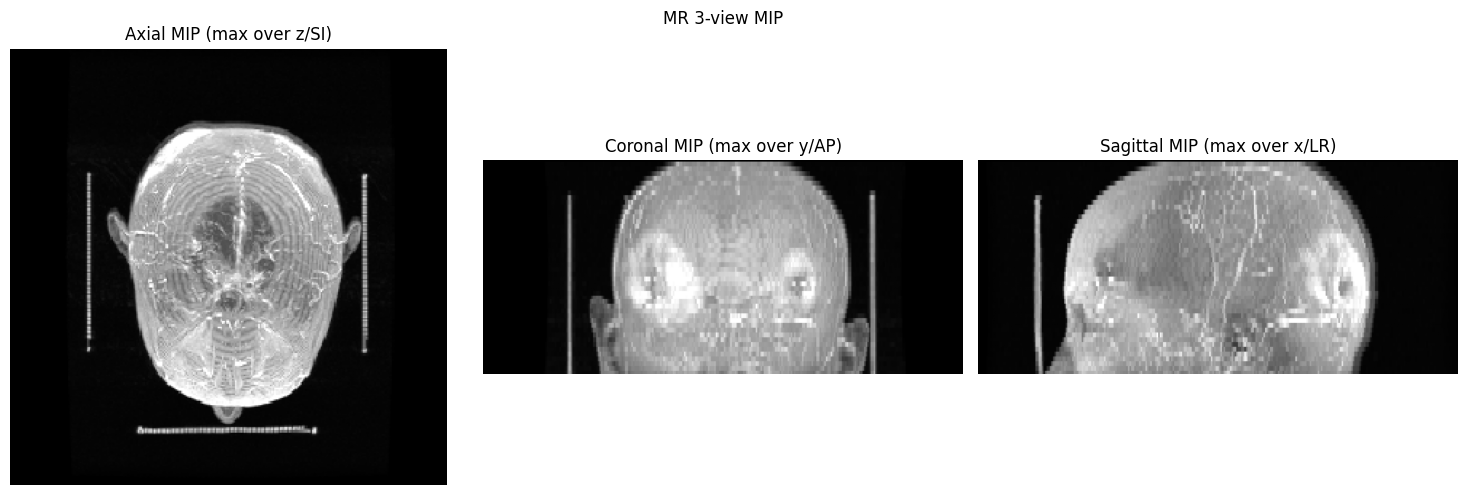

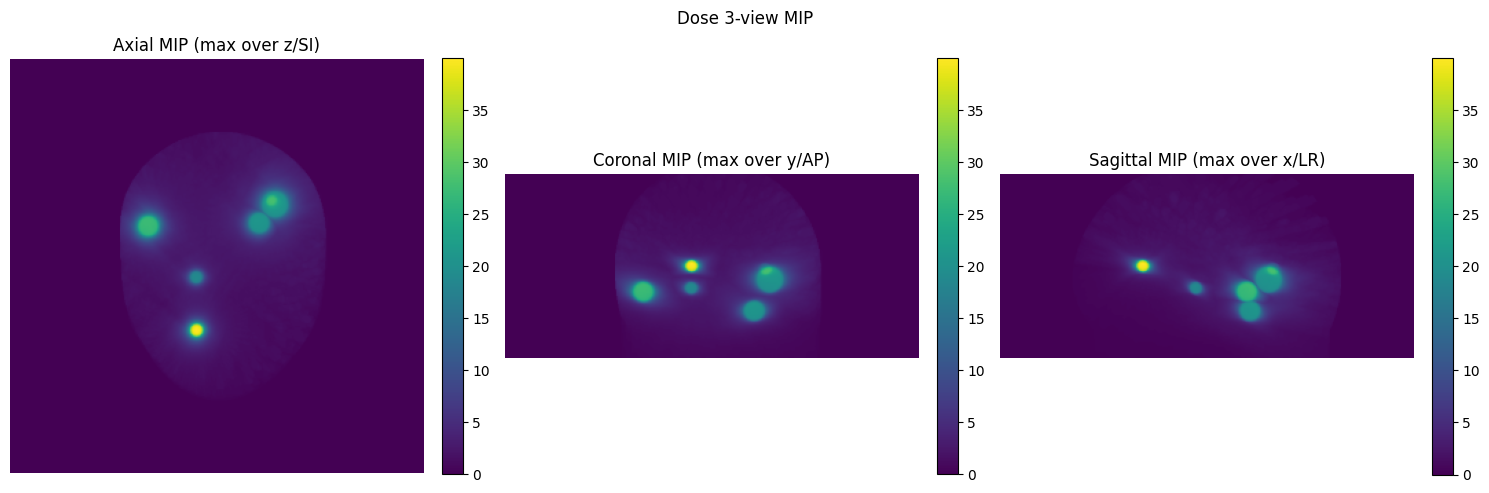

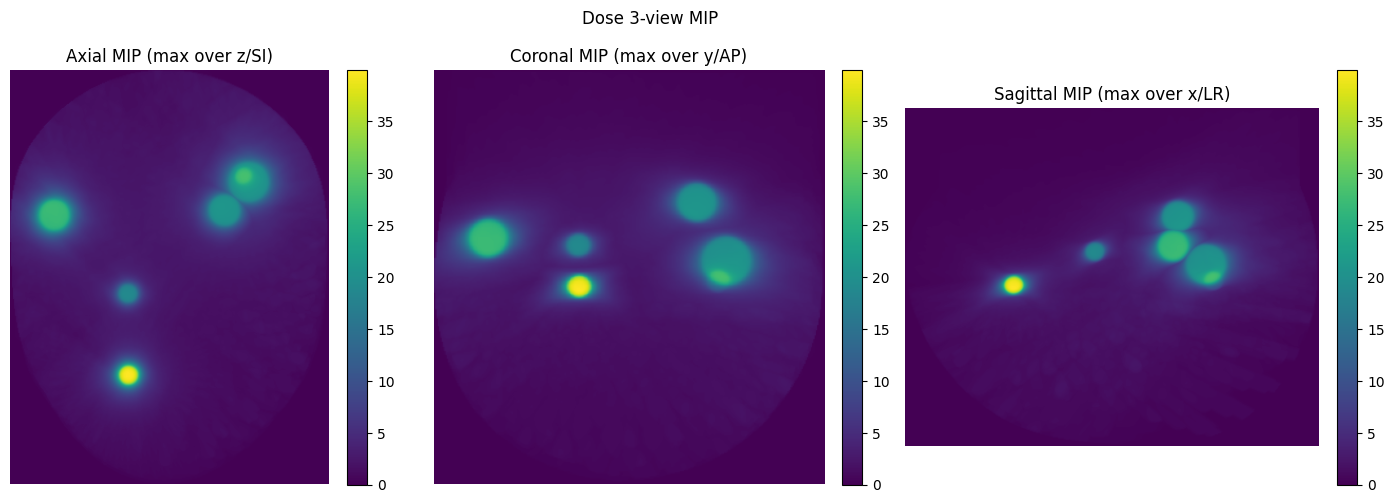

(<Figure size 1500x500 with 6 Axes>,
 array([<Axes: title={'center': 'Axial MIP (max over z/SI)'}>,
        <Axes: title={'center': 'Coronal MIP (max over y/AP)'}>,
        <Axes: title={'center': 'Sagittal MIP (max over x/LR)'}>],
       dtype=object))

In [7]:
vmin_rtdose = 0
vmax_rtdose = np.max(sitk.GetArrayFromImage(rtdose_img).astype(np.float32))
print(f"vmin_rtdose: {vmin_rtdose}, vmax_rtdose: {vmax_rtdose}")
plot_3view_mip(sitk.GetArrayFromImage(mr_img_iso).astype(np.float32), cmap="gray", suptitle="MR 3-view MIP")
plot_3view_mip(sitk.GetArrayFromImage(rtdose_img_iso).astype(np.float32), assume_nonnegative=True, suptitle="Dose 3-view MIP", add_colorbar=True, vmin=vmin_rtdose, vmax=vmax_rtdose)
plot_3view_mip(sitk.GetArrayFromImage(rtdose_img).astype(np.float32), assume_nonnegative=True, suptitle="Dose 3-view MIP", add_colorbar=True, vmin=vmin_rtdose, vmax=vmax_rtdose)

(134, 301, 301)
(134, 301, 301)


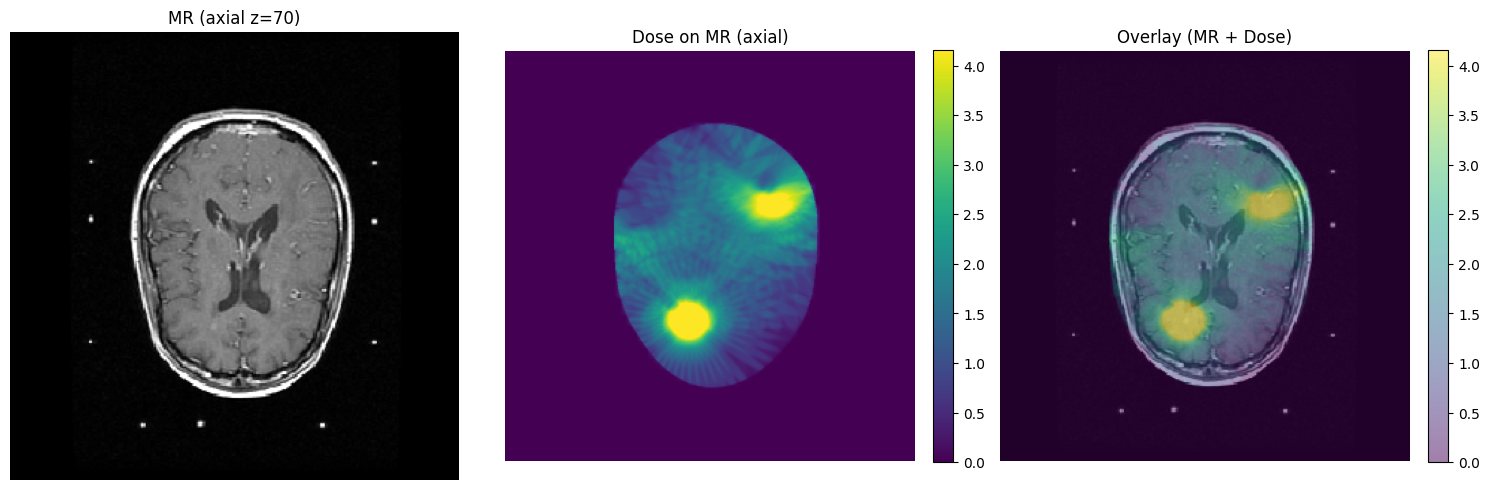

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

# Convert SimpleITK images -> numpy (z, y, x)
mr_np   = sitk.GetArrayFromImage(mr_img_iso).astype(np.float32)
dose_np = sitk.GetArrayFromImage(rtdose_img_iso).astype(np.float32)
print(mr_np.shape)
print(dose_np.shape)
# Central axial slice index
z0 = mr_np.shape[0] // 2
z0 = 10
z0 = 70

mr_sl   = mr_np[z0, :, :]
dose_sl = dose_np[z0, :, :]

# Robust windowing for MR display
p1, p99 = np.percentile(mr_sl[np.isfinite(mr_sl)], [1, 99])
mr_disp = np.clip(mr_sl, p1, p99)

# Robust scaling for dose display
# (Often dose is 0 outside the grid; keep 0 as baseline)
dose_valid = dose_sl[np.isfinite(dose_sl)]
dmax = np.percentile(dose_valid, 99) if np.any(dose_valid) else 0.0
dmax = float(dmax) if dmax > 0 else float(np.max(dose_sl))  # fallback

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1) MR
axes[0].imshow(mr_disp, cmap="gray", origin="lower")
axes[0].set_title(f"MR (axial z={z0})")
axes[0].axis("off")

# 2) Dose
im1 = axes[1].imshow(dose_sl, origin="lower", vmin=0, vmax=dmax)
axes[1].set_title("Dose on MR (axial)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# 3) Overlay (MR + dose heatmap with alpha)
axes[2].imshow(mr_disp, cmap="gray", origin="lower")

if dmax > 0:
    alpha = np.clip(dose_sl / dmax, 0, 1) * 0.8  # 0..0.8 transparency
else:
    alpha = 0.0

im2 = axes[2].imshow(dose_sl, origin="lower", vmin=0, vmax=dmax, alpha=0.5)
axes[2].set_title("Overlay (MR + Dose)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
